In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from scipy.linalg import block_diag
import scipy as sc
import sympy as sp


import rover as rover_class
import grid_world
from astar_plan import AStarPlanner

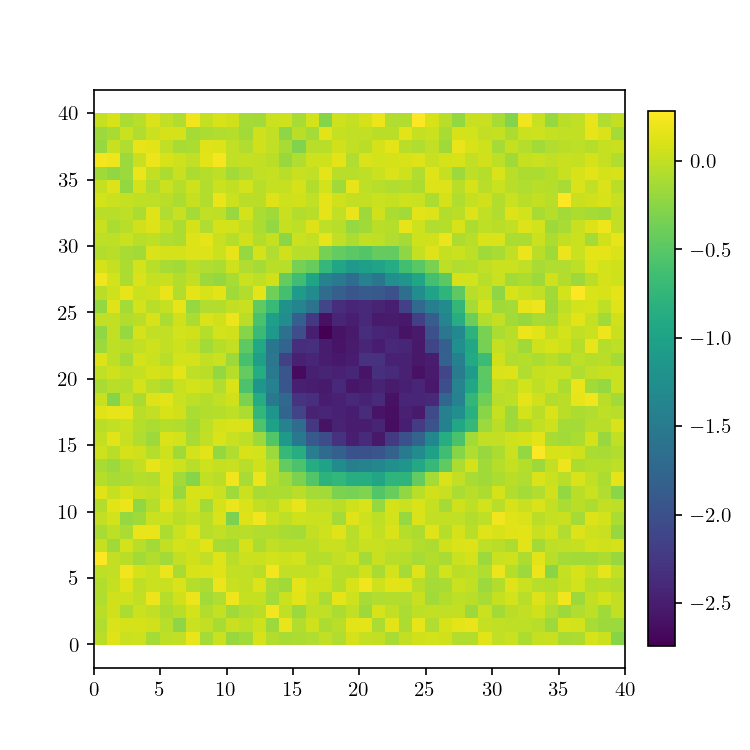

In [45]:
# rover
# assume the user is at the Poincare crater (in rad)
lat_user = np.deg2rad(-59.12448)
lon_user = np.deg2rad(161.05104)
# can initialize the rover with the desired initial location
rover = rover_class.Rover_Agent([lat_user, lon_user])
# TODO: need to make the state actually the rover state
rover_state = rover.rover_loc

N_t = 100          # number of time steps

# create a grid (specify number of cells and cell resolution)
grid_env = grid_world.GridWorld(40, 1, N_t, rover.rover_loc, 0.0, 0.1)
# let's add some craters (if you do not specify location, they will be randomly placed)
# crater = grid_env.create_crater(10, 5)
# grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(10, 2.5, [20, 20])
grid_env.add_crater(crater, slope_factor=0.5)
fig, ax = grid_env.plot_grid_elev()

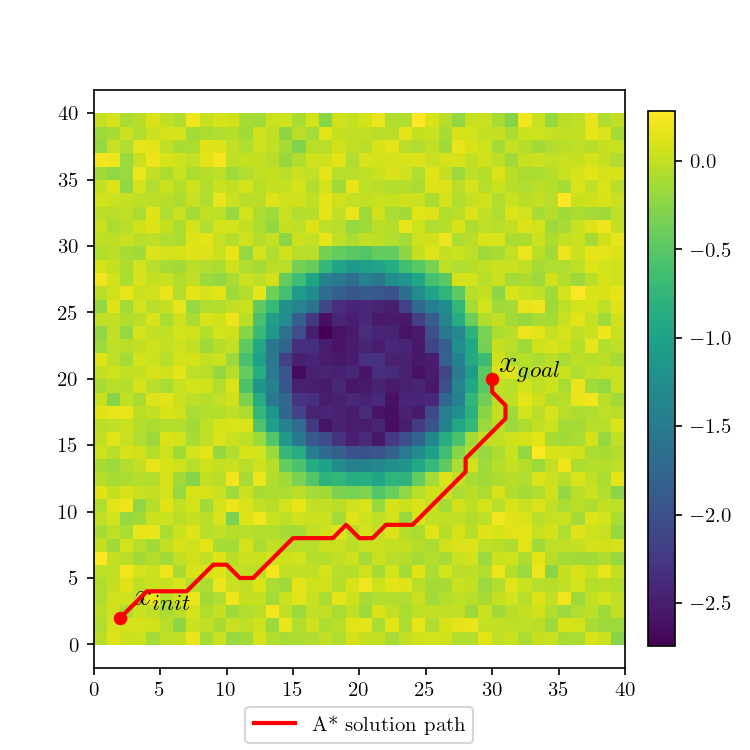

In [53]:
grid_obj = grid_env.get_grid()
resolution = grid_env.res

x_init = (2,2)
x_goal = (30,20)
# from AA274A --> needed lower bound tuple, upper bound tuple, initial state tuple, goal state tuple, occupancy as the grid, and resolution
# obstacles = [((6,7),(8,8)),((2,2),(4,3)),((2,5),(4,7)),((6,3),(8,5))]
# obstacles = [((0,7),(15,15)), ((25,22),(40,30))]
obstacles = None
astar = AStarPlanner((0, 0), (grid_env.N, grid_env.N), x_init, x_goal, grid_env, resolution, True, obstacles)

if not astar.solve():
    print("No path found")
else:
    path_plan = astar.path
    plt.rcParams['figure.figsize'] = [5, 5]
    astar.plot_path()
    # astar.plot_tree()

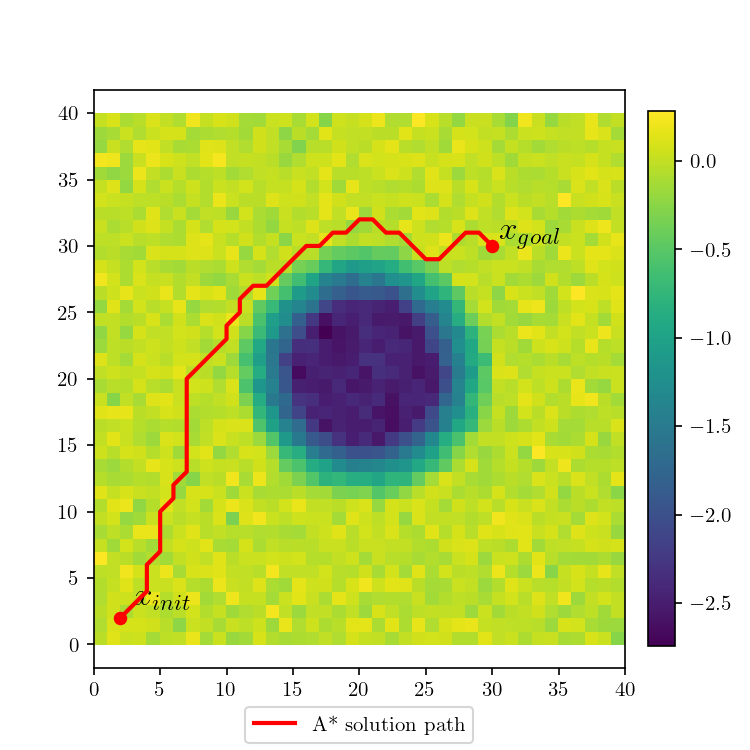

In [82]:
x_init = (5,5)
x_goal = (30,30)
# from AA274A --> needed lower bound tuple, upper bound tuple, initial state tuple, goal state tuple, occupancy as the grid, and resolution
# obstacles = [((6,7),(8,8)),((2,2),(4,3)),((2,5),(4,7)),((6,3),(8,5))]
# obstacles = [((0,7),(15,15)), ((25,22),(40,30))]
obstacles = None
astar = AStarPlanner((0, 0), (grid_env.N, grid_env.N), x_init, x_goal, grid_env, resolution, True, obstacles, elev_weight = 10)

if not astar.solve():
    print("No path found")
else:
    path_plan = astar.path
    plt.rcParams['figure.figsize'] = [5, 5]
    astar.plot_path()
    # astar.plot_tree()

Text(0.5, 0, 'Elevation [m]')

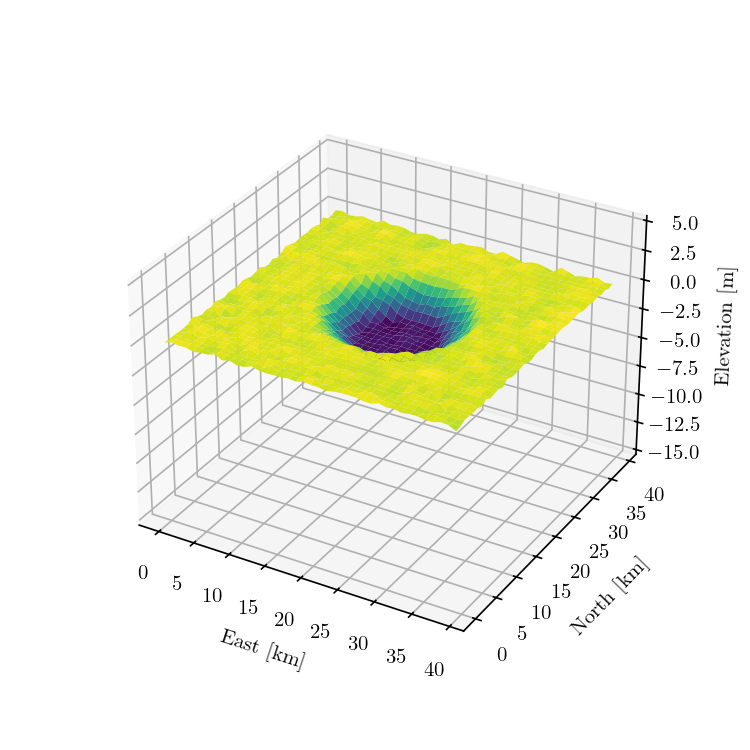

In [81]:
# plot the grid elevation as a 3d histogram
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111, projection='3d')
x = np.arange(grid_obj.shape[0])
y = np.arange(grid_obj.shape[1])
X, Y = np.meshgrid(x, y)
# elevation along path
elev = np.zeros((3,len(path_plan)))
for i, p in enumerate(path_plan):
    elev[:,i] = [p[0], p[1], grid_obj[p[0], p[1], 0, 0]]
# ax.plot(elev[0,:], elev[1,:], elev[2,:], '.-', color = 'r', linewidth=2, markersize=10)

ax.plot_surface(X, Y, grid_obj[:,:,0,0], cmap='viridis')
ax.set_zlim(-15, 5)
ax.set_xlabel('East [km]')
ax.set_ylabel('North [km]')
ax.set_zlabel('Elevation [m]')
